In [1]:
#Imports
import pandas as pd
import yfinance as yf
import numpy as np
yf.set_tz_cache_location("C:/Users/skous/PycharmProhects/Recplay/cache/py-yfinance")

[*********************100%***********************]  1 of 1 completed


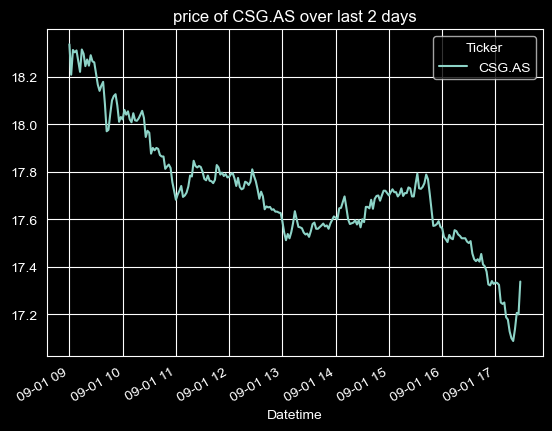

In [2]:
ticker = "CSG.AS"
df = yf.download(ticker, start= "2026-09-01", end= "2026-09-02", interval= "2m", prepost= True)

df.plot(y= "Close", kind= "line", title= f"price of {ticker} over last 2 days")
Series = df["Close"].squeeze("columns").to_numpy()

In [3]:
Series.shape

(251,)

In [4]:
m = 4 # Embedd dim
t = 4 # Delay

ε = 0.3 # Self explanatory

#MATRIX
windows = np.lib.stride_tricks.sliding_window_view(Series, (m - 1) * t + 1)
vectors = windows[:, ::t] #VECTORS

In [5]:
Raw = np.zeros((len(vectors),len(vectors)),dtype= float)
Thresholded = np.zeros((len(vectors),len(vectors)),dtype= float)


for i in range(len(vectors)):
    for j in range(len(vectors)):
        Δ = (vectors[i] - vectors[j]) ** 2
        D = np.sqrt(np.sum(Δ))

        Raw[i,j] = D
        Raw[j,i] = D

        Thresholded[i,j] = D <= ε
        Thresholded[j,i] = D <= ε

In [6]:
 import matplotlib.pyplot as plt

## Raw

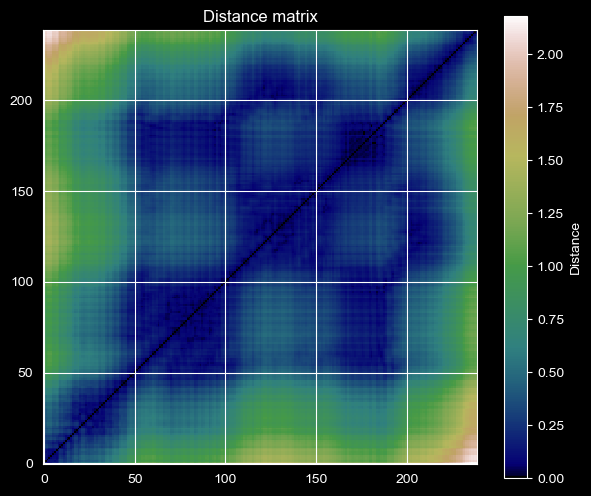

In [18]:
fig1, ax1 = plt.subplots(figsize=(7, 6))
im = ax1.imshow(Raw, cmap="gist_earth", origin="lower", interpolation="nearest")

ax1.set_title("Distance matrix")

fig1.colorbar(im, ax=ax1, label="Distance")
plt.show()

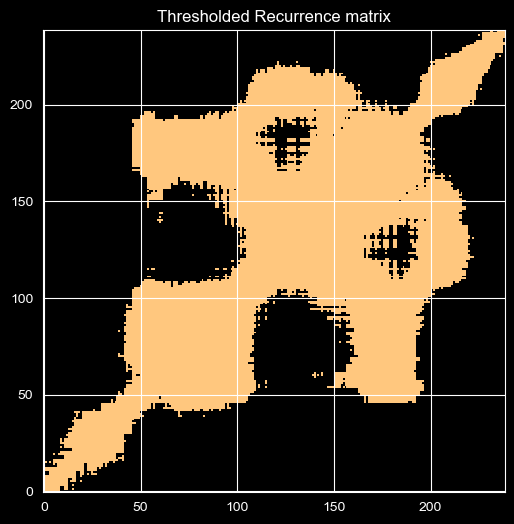

In [19]:
fig2, ax2 = plt.subplots(figsize=(7, 6))
im = ax2.imshow(Thresholded, cmap="copper", origin="lower", interpolation="nearest")

ax2.set_title("Thresholded Recurrence matrix")

#fig1.colorbar(im, ax=ax1, label="Distance")
plt.show()